In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek


In [39]:
df= pd.read_csv('Heart_Disease_Prediction.csv')

In [40]:
df.shape #it defines rows and columns there 274 rows and 14 columns

(274, 14)

In [41]:
df.info() #infomation of rows and columns.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      273 non-null    float64
 1   Gender                   273 non-null    float64
 2   Chest pain type          272 non-null    float64
 3   BP                       273 non-null    float64
 4   Cholesterol              273 non-null    float64
 5   FBS over 120             273 non-null    float64
 6   EKG results              273 non-null    float64
 7   Max HR                   273 non-null    float64
 8   Exercise angina          273 non-null    float64
 9   ST depression            273 non-null    float64
 10  Slope of ST              273 non-null    float64
 11  Number of vessels fluro  273 non-null    float64
 12  Thallium                 273 non-null    float64
 13  Heart Disease            273 non-null    object 
dtypes: float64(13), object(1)


In [42]:
df.dtypes # get datatypes

Age                        float64
Gender                     float64
Chest pain type            float64
BP                         float64
Cholesterol                float64
FBS over 120               float64
EKG results                float64
Max HR                     float64
Exercise angina            float64
ST depression              float64
Slope of ST                float64
Number of vessels fluro    float64
Thallium                   float64
Heart Disease               object
dtype: object

In [45]:
df.columns #iterative columns used in futher code 

Index(['Age', 'Gender', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')

In [46]:
df.describe()

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,273.000000,273.000000,272.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000
mean,54.454212,0.681319,3.165441,131.366300,249.967033,0.146520,1.025641,149.648352,0.329670,1.050549,1.586081,0.673993,4.692308
std,9.115210,0.466821,0.951897,17.874087,51.495171,0.354276,0.997829,23.227317,0.470957,1.141887,0.613054,0.950977,1.940431
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,154.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,282.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [47]:
df.head() #1st 5 rows

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70.0,1.0,4.0,130.0,322.0,0.0,2.0,109.0,0.0,2.4,2.0,3.0,3.0,Presence
1,67.0,0.0,3.0,115.0,564.0,0.0,2.0,160.0,0.0,1.6,2.0,0.0,7.0,Absence
2,57.0,1.0,2.0,124.0,261.0,0.0,0.0,141.0,0.0,0.3,1.0,0.0,7.0,Presence
3,64.0,1.0,4.0,128.0,263.0,0.0,0.0,105.0,1.0,0.2,2.0,1.0,7.0,Absence
4,74.0,0.0,2.0,120.0,269.0,0.0,2.0,121.0,1.0,0.2,1.0,1.0,3.0,Absence


In [48]:
df.tail() #last 5 rows

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
269,44.0,1.0,2.0,120.0,263.0,0.0,0.0,173.0,0.0,0.0,1.0,0.0,7.0,Absence
270,56.0,0.0,2.0,140.0,294.0,0.0,2.0,153.0,0.0,1.3,2.0,0.0,3.0,Absence
271,57.0,1.0,4.0,140.0,192.0,0.0,0.0,148.0,0.0,0.4,2.0,0.0,6.0,Absence
272,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,Presence
273,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,Presence


In [49]:
df.nunique()

Age                         41
Gender                       2
Chest pain type              4
BP                          47
Cholesterol                144
FBS over 120                 2
EKG results                  3
Max HR                      90
Exercise angina              2
ST depression               39
Slope of ST                  3
Number of vessels fluro      4
Thallium                     3
Heart Disease                2
dtype: int64

In [50]:
# remove Duplicates 
print(df.duplicated().sum())

3


In [51]:
df.drop_duplicates(inplace=True)
# df=df.drop_duplicated()

In [52]:
#handle Null Values
df.isnull().sum()

Age                        1
Gender                     1
Chest pain type            2
BP                         1
Cholesterol                1
FBS over 120               1
EKG results                1
Max HR                     1
Exercise angina            1
ST depression              1
Slope of ST                1
Number of vessels fluro    1
Thallium                   1
Heart Disease              1
dtype: int64

In [53]:
df.dropna(how='all',inplace=True) #by default 
#df.dropna(how='any',inplace=True)

In [54]:
for col in df.columns:
    if df[col].dtype=='object':
        df[col]==df[col].fillna(df[col].mode()[0])
    else:
        df[col]=df[col].fillna(df[col].median())

In [55]:
columns_to_scale=['Age','BP','Cholesterol','Max HR','ST depression' ] #target x , categoriol
scaler=StandardScaler()
df[columns_to_scale]=scaler.fit_transform(df[columns_to_scale])


In [56]:
df.head()

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,1.712094,1.0,4.0,-0.075410,1.402212,0.0,2.0,-1.759208,0.0,1.181012,2.0,3.0,3.0,Presence
1,1.382140,0.0,3.0,-0.916759,6.093004,0.0,2.0,0.446409,0.0,0.481153,2.0,0.0,7.0,Absence
2,0.282294,1.0,2.0,-0.411950,0.219823,0.0,0.0,-0.375291,0.0,-0.656118,1.0,0.0,7.0,Presence
3,1.052186,1.0,4.0,-0.187590,0.258589,0.0,0.0,-1.932198,1.0,-0.743600,2.0,1.0,7.0,Absence
4,2.152032,0.0,2.0,-0.636310,0.374890,0.0,2.0,-1.240239,1.0,-0.743600,1.0,1.0,3.0,Absence


In [57]:
df['Heart Disease']=LabelEncoder().fit_transform(df['Heart Disease'])

In [58]:
df.head()

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,1.712094,1.0,4.0,-0.075410,1.402212,0.0,2.0,-1.759208,0.0,1.181012,2.0,3.0,3.0,1
1,1.382140,0.0,3.0,-0.916759,6.093004,0.0,2.0,0.446409,0.0,0.481153,2.0,0.0,7.0,0
2,0.282294,1.0,2.0,-0.411950,0.219823,0.0,0.0,-0.375291,0.0,-0.656118,1.0,0.0,7.0,1
3,1.052186,1.0,4.0,-0.187590,0.258589,0.0,0.0,-1.932198,1.0,-0.743600,2.0,1.0,7.0,0
4,2.152032,0.0,2.0,-0.636310,0.374890,0.0,2.0,-1.240239,1.0,-0.743600,1.0,1.0,3.0,0


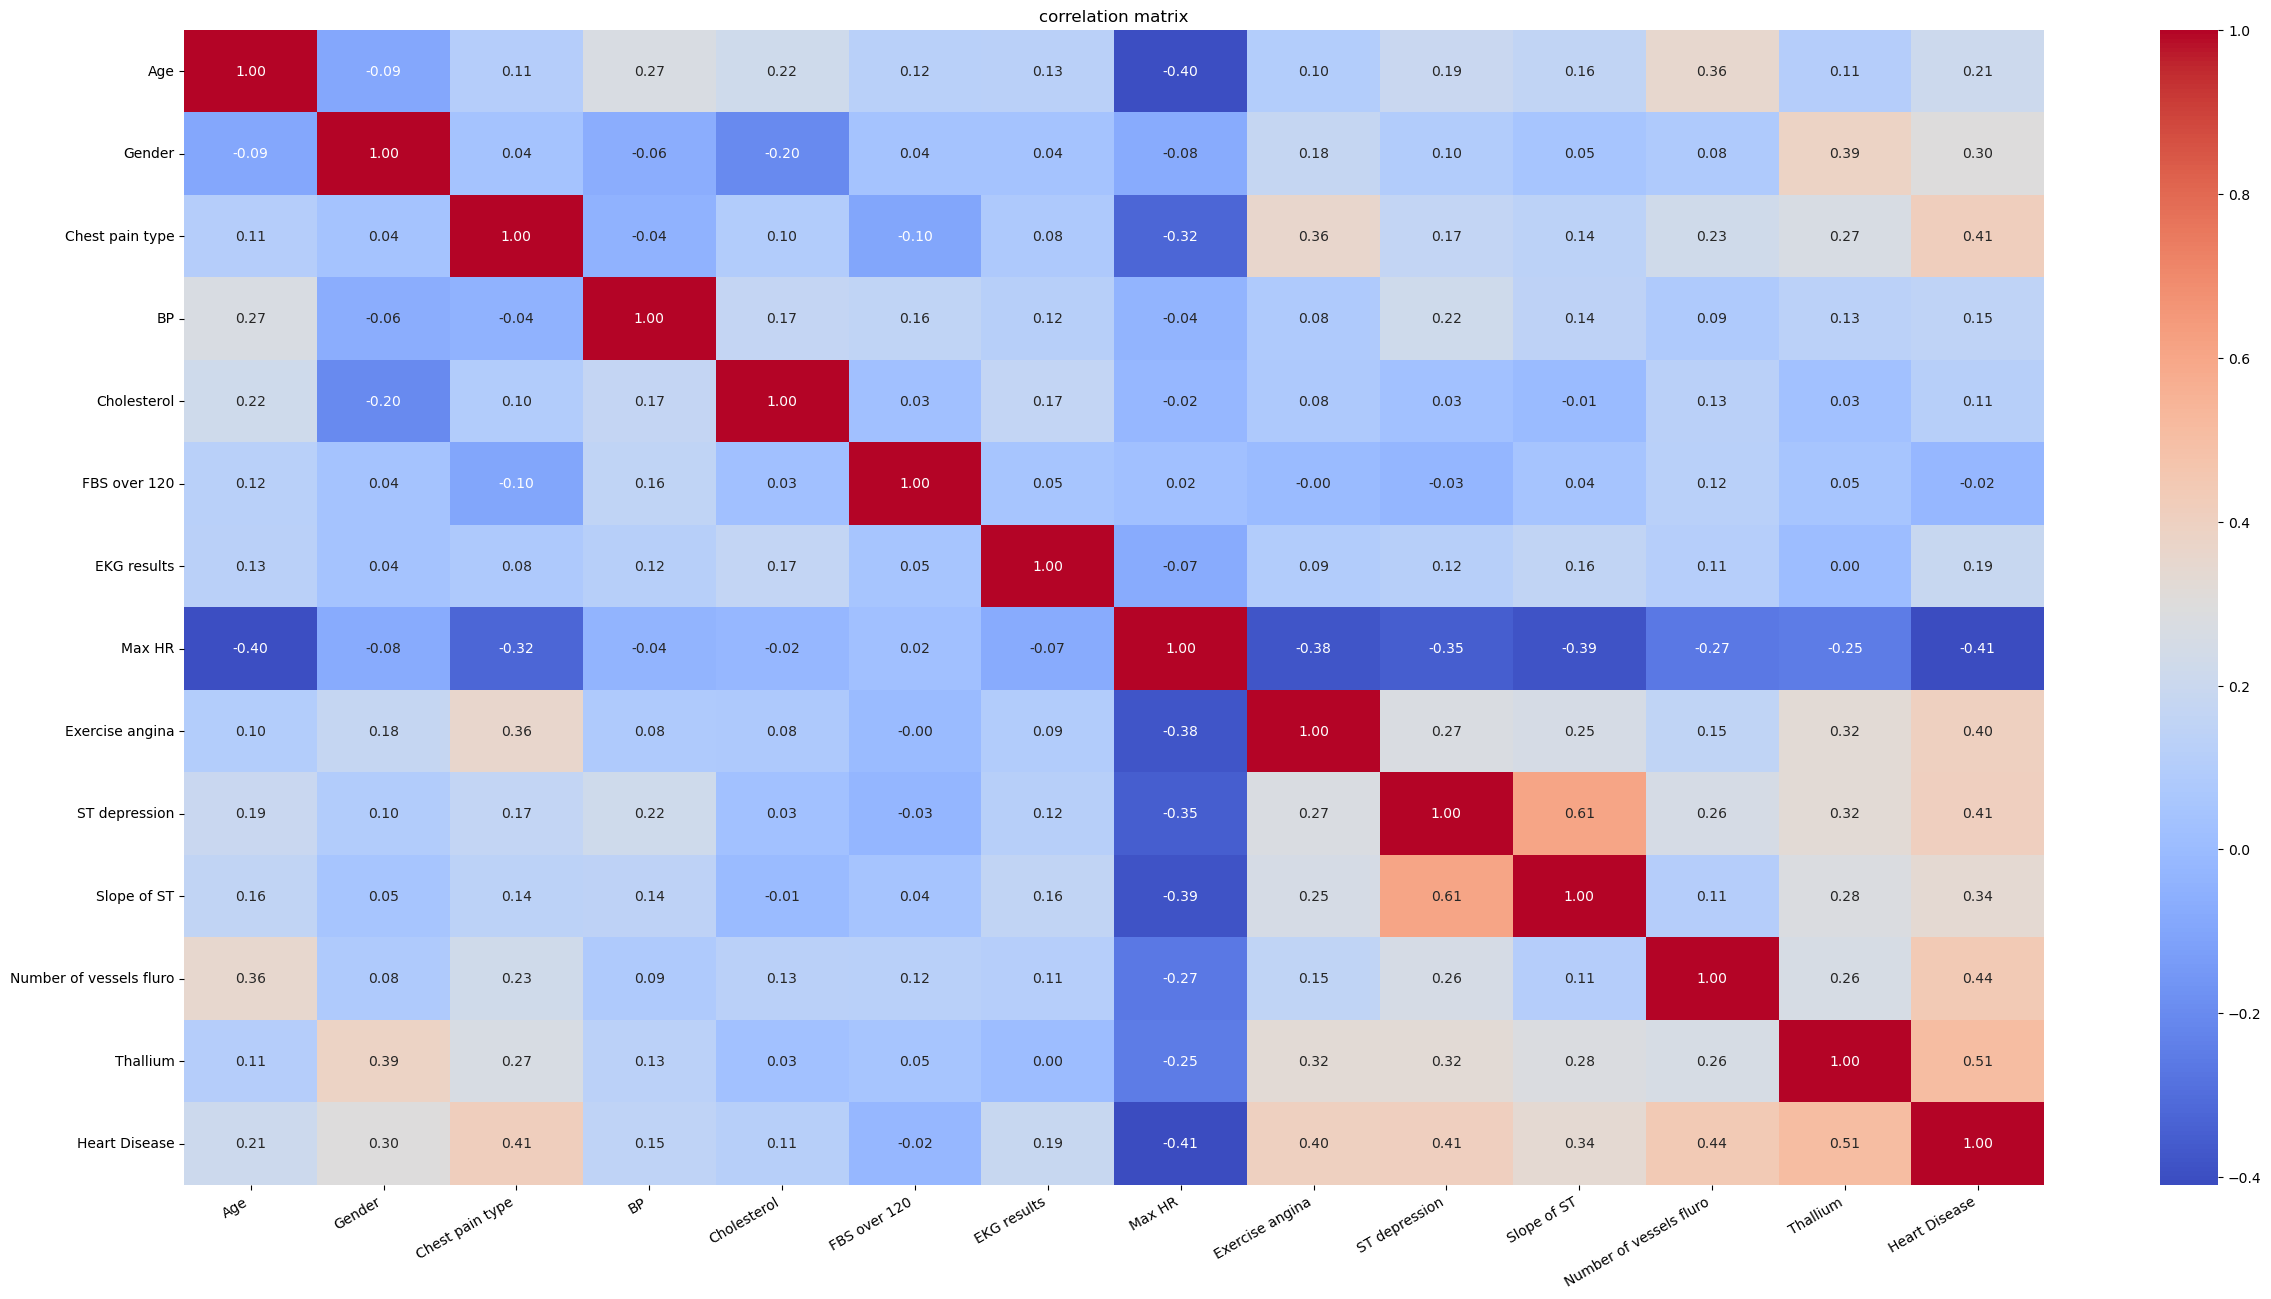

In [34]:
corr_matrix= df.corr()
plt.figure(figsize=(30,15))
sns.heatmap(corr_matrix,annot= True, cmap='coolwarm',fmt='.2f')
plt.title('correlation matrix')
plt.xticks(rotation = 30,ha='right')
plt.show()

In [59]:
df.drop(columns=['Age'],inplace=True)

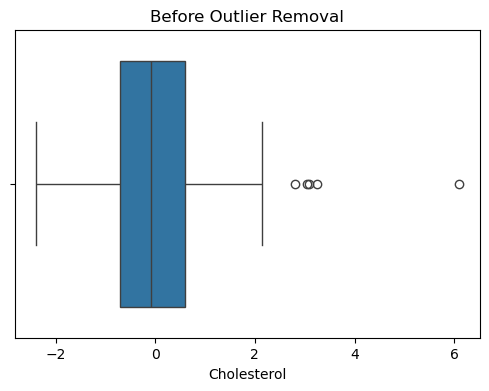

In [61]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Cholesterol'])
plt.title('Before Outlier Removal')
plt.show()

In [68]:
Q1 = df['Cholesterol'].quantile(0.25)
Q3 = df['Cholesterol'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Cholesterol'] >= lower_bound) & (df['Cholesterol'] <= upper_bound)]


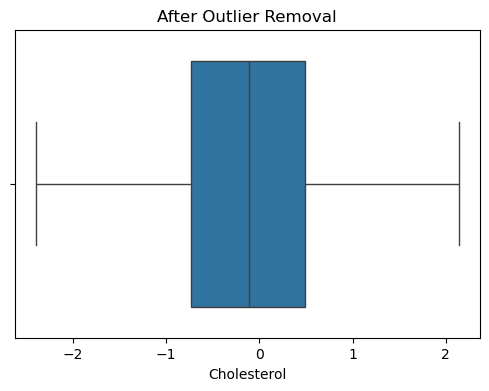

In [69]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Cholesterol'])
plt.title('After Outlier Removal')
plt.show()

In [70]:
print(df['Heart Disease'].value_counts())

Heart Disease
0    147
1    118
Name: count, dtype: int64


In [73]:
x=df.drop(columns=['Heart Disease'])
y=df['Heart Disease']


In [74]:
print(f"Original Size:\n{y.value_counts()}")
# balance=SMOTE(random_state=42)
# balance=SMOTETomek(random_state=42)
balance = SMOTETomek(random_state=42)
x_resampled, y_resampled = balance.fit_resample(x, y)
print(f"Resampled Size:\n{y_resampled.value_counts()}")

Original Size:
Heart Disease
0    147
1    118
Name: count, dtype: int64
Resampled Size:
Heart Disease
1    134
0    134
Name: count, dtype: int64


In [76]:
df=pd.concat([x,y],axis=1)
df.to_csv('Updated.csv',index=False)